In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
df=pd.read_csv("../data/synthetic_food_delivery_transactions.csv")
df

,order_id,customer_id,customer_loyalty_tier,customer_acquisition_channel,customer_signup_date,restaurant_id,restaurant_cuisine,restaurant_city,restaurant_rating,restaurant_avg_prep_time,...,total_amount,discount_code,discount_type,discount_value,order_status,weather_temperature,weather_precipitation,is_weekend,is_holiday,event_flag
0,4002,925,Gold,social_media,22-07-2024,124,American,Los Angeles,3.6,23,...,25.42,PROMO-BFUZ,percentage,4.97,completed,2.9,25.6,True,True,NaN
1,4879,3163,Bronze,referral,17-03-2023,43,Chinese,Houston,4.8,32,...,22.70,NaN,NaN,0.00,completed,4.0,0.4,True,True,NaN
2,1124,4154,Bronze,referral,14-01-2023,188,American,San Antonio,3.4,11,...,27.74,NaN,NaN,0.00,completed,4.4,0.0,True,True,NaN
3,6764,4530,Bronze,email,26-02-2024,91,Mediterranean,New York,3.1,17,...,31.85,NaN,NaN,0.00,completed,9.9,0.0,True,True,NaN
4,9073,2570,Bronze,paid_ads,25-08-2024,84,Mediterranean,San Antonio,3.2,28,...,28.46,NaN,NaN,0.00,completed,7.0,16.1,True,True,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,6028,7849,Bronze,referral,26-06-2024,122,Mexican,Phoenix,4.4,18,...,43.34,NaN,NaN,0.00,completed,4.7,0.0,False,False,NaN
9996,6760,330,Silver,social_media,28-07-2023,103,Chinese,Chicago,4.1,30,...,135.07,NaN,NaN,0.00,cancelled,7.4,0.0,False,False,NaN
9997,3727,5447,Silver,organic,11-06-2023,173,Fast Food,Los Angeles,3.2,32,...,11.63,NaN,NaN,0.00,completed,7.5,0.0,False,False,NaN
9998,9730,8202,Bronze,social_media,17-12-2023,141,Mediterranean,Chicago,4.0,33,...,29.69,NaN,NaN,0.00,completed,3.4,0.0,False,False,NaN


In [5]:
# Number of columns and rows
print(f'This DataFrame is having {df.shape[0]} rows and {df.shape[1]} columns.')

This DataFrame is having 10000 rows and 31 columns.


In [6]:
# customer_signup_date, order_timestamp, delivery_timestamp is having Dtype as object, so we need to convert it into date.

df["customer_signup_date"] = pd.to_datetime(df["customer_signup_date"], format='%d-%m-%Y')
df["order_timestamp"] = pd.to_datetime(df["order_timestamp"], format='%d-%m-%Y %H:%M')
df["delivery_timestamp"] = pd.to_datetime(df["delivery_timestamp"], format='%d-%m-%Y %H:%M')

In [7]:
'''ID columns as int64 - order_id, customer_id, restaurant_id and menu_item_id are integers but are identifiers, not quantities.
They shouldn't be used in any numerical aggregations.'''

id_cols=['order_id', 'customer_id', 'restaurant_id', 'menu_item_id']
df[id_cols] = df[id_cols].astype(str)

In [8]:
import datetime as dt

In [9]:
df['hour'] = pd.to_datetime(df['order_timestamp']).dt.hour
df['month_name'] = pd.to_datetime(df['order_timestamp']).dt.month_name()

df['Time_of_Day'] = ''
df.loc[(df['hour'] >= 5) & (df['hour'] < 12), 'Time_of_Day'] = 'Morning'
df.loc[(df['hour'] >= 12) & (df['hour'] < 16), 'Time_of_Day'] = 'Afternoon'
df.loc[(df['hour'] >= 16) & (df['hour'] < 21), 'Time_of_Day'] = 'Evening'
df.loc[(df['hour'] >= 21) | (df['hour'] < 5), 'Time_of_Day'] = 'Night'

df[['Time_of_Day','month_name']]

# First we extracted hour from 'order timestamp' column and then created a new column 'Time of day' and in the same way 'month name was extracted'.

,Time_of_Day,month_name
0,Night,January
1,Night,January
2,Night,January
3,Morning,January
4,Morning,January
...,...,...
9995,Afternoon,December
9996,Afternoon,December
9997,Evening,December
9998,Evening,December


In [10]:
df.isnull().sum()

order_id                           0
customer_id                        0
customer_loyalty_tier              0
customer_acquisition_channel       0
customer_signup_date               0
restaurant_id                      0
restaurant_cuisine                 0
restaurant_city                    0
restaurant_rating                  0
restaurant_avg_prep_time           0
menu_item_id                       0
menu_item_name                     0
menu_item_category                 0
item_price                         0
quantity                           0
order_timestamp                    0
delivery_timestamp               775
delivery_duration_actual         775
delivery_duration_estimated        0
delivery_fee                       0
tip                                0
total_amount                       0
discount_code                   8050
discount_type                   8050
discount_value                     0
order_status                       0
weather_temperature                0
w

In [11]:
# Handling Null Values:
'''Created a new clean numeric column which directly answers "did this order have a discount?" -
which is much easier to use in groupby and visualizations.'''

df['has_discount'] = df['discount_code'].notnull().astype(int)

In [12]:
# How many orders were cancelled?

cancelled_orders=df[df['delivery_timestamp'].isnull()]['order_status'].value_counts()['cancelled']
print(f"{cancelled_orders} orders were cancelled.")

775 orders were cancelled.


In [13]:
# Filtering out Cancelled Orders

df_delivered = df[df['order_status'] == 'completed']

## Average Key Metrics:

In [14]:
print("Avg Order Value  :", df['total_amount'].mean().round(2))
print("Avg Delivery Time:", df_delivered['delivery_duration_actual'].mean().round(2))
print("Avg Tip          :", df['tip'].mean().round(2))
print("Avg Delivery Fee :", df['delivery_fee'].mean().round(2))
print("Avg Item Price   :", df['item_price'].mean().round(2))

Avg Order Value  : 35.29
Avg Delivery Time: 48.25
Avg Tip          : 3.46
Avg Delivery Fee : 5.02
Avg Item Price   : 20.14


In [15]:
# checking all the unique value of all loyalty levels.

# CUSTOMER LOYALTY TIER IS STORED IN loyalty_tiers.

loyalty_tiers = pd.DataFrame(df['customer_loyalty_tier'].unique())
loyalty_tiers

,0
0,Gold
1,Bronze
2,Silver


In [16]:
# this shows how the customer originally signed up.

# CUSTOMER AQUISITION CHANNEL IS STORED IN acquisition_channels.

acquisition_channels = pd.DataFrame(df['customer_acquisition_channel'].unique())
acquisition_channels

,0
0,social_media
1,referral
2,email
3,paid_ads
4,organic


## **Outliers**

In [17]:
# Create a function to find outliers and apply the function on a DataFrame
def Outliers(data,col):
  q1=data[col].quantile(0.25)
  q3=data[col].quantile(0.75)
  IQR=q3-q1
  lower_fence=q1-1.5*(IQR)
  upper_fence=q3+1.5*(IQR)
  outlier=data[(data[col]<lower_fence)|(data[col]>upper_fence)]
  return lower_fence,upper_fence,outlier

In [18]:
col = ['total_amount','delivery_duration_actual', 'tip',
       'delivery_fee', 'item_price', 'restaurant_avg_prep_time']

for cl in col:
    lf, uf, outlr = Outliers(df, cl)
    print(f"\nColumn : {cl}")
    print("Lower Fence :", lf)
    print("Upper Fence :", uf)
    print("Count of Outliers :", outlr.shape[0])


Column : total_amount
Lower Fence : -8.476250000000004
Upper Fence : 69.61375
Count of Outliers : 810

Column : delivery_duration_actual
Lower Fence : 16.0
Upper Fence : 80.0
Count of Outliers : 21

Column : tip
Lower Fence : -4.05125
Upper Fence : 9.75875
Count of Outliers : 534

Column : delivery_fee
Lower Fence : -0.9850000000000008
Upper Fence : 11.055
Count of Outliers : 0

Column : item_price
Lower Fence : -9.805
Upper Fence : 49.915
Count of Outliers : 0

Column : restaurant_avg_prep_time
Lower Fence : -2.0
Upper Fence : 46.0
Count of Outliers : 0


## **Customer Behaviour**

1. Which loyalty tier places the most orders vs Which spends the most?

In [19]:
# orders by loyalty tier
orders_by_tier = df.groupby('customer_loyalty_tier')['order_id'].count().sort_values(ascending=False)
print(orders_by_tier)

# avg spend by loyalty tier
spend_by_tier = df.groupby('customer_loyalty_tier')['total_amount'].mean().round(2).sort_values(ascending=False)
print(spend_by_tier)

customer_loyalty_tier
Bronze    6042
Silver    3041
Gold       917
Name: order_id, dtype: int64
customer_loyalty_tier
Silver    36.33
Gold      35.45
Bronze    34.74
Name: total_amount, dtype: float64


 2. Which acquisition channel brings in the highest value customers?

In [20]:
# orders by acquisition channel
orders_by_channel = df.groupby('customer_acquisition_channel')['order_id'].count().sort_values(ascending=False)
print(orders_by_channel)

# avg spend by acquisition channel
spend_by_channel = df.groupby('customer_acquisition_channel')['total_amount'].mean().round(2).sort_values(ascending=False)
print(spend_by_channel)

customer_acquisition_channel
paid_ads        2028
email           2022
social_media    2008
referral        1981
organic         1961
Name: order_id, dtype: int64
customer_acquisition_channel
email           35.94
organic         35.78
referral        35.08
social_media    34.91
paid_ads        34.72
Name: total_amount, dtype: float64


3. Do older customers (early signup date) order more than newer ones?

In [21]:
# extract signup year first
df['signup_year'] = df['customer_signup_date'].dt.year

# orders by signup year
orders_by_signup = df.groupby('signup_year')['order_id'].count()
print(orders_by_signup)

signup_year
2023    5056
2024    4944
Name: order_id, dtype: int64


### Key findings from the data:
* Bronze tier dominates in order count (6,042) but Silver spends the most on average ($36.33) - loyalty tier and spending don't move together

* All aquisition channels are nearly equal in volume (~2,000 each) - no single channel dominates but email brings in the highest value customers  ($35.94 avg.)

* 2023 and 2024 signups are almost equal in orders - no strong signal that older customers order more


## **Delivery Performance**
1. Which city has the best & worst delivery performance?

In [22]:
delivery_by_city = df_delivered.groupby('restaurant_city')['delivery_duration_actual'].mean().round(2).sort_values(ascending=False)
print(delivery_by_city)

restaurant_city
Phoenix         50.05
San Antonio     49.60
Philadelphia    49.58
San Diego       49.36
Houston         48.83
Chicago         47.63
New York        46.79
Los Angeles     44.73
Name: delivery_duration_actual, dtype: float64


2. Which restaurants consistently exceed their estimated delivery time?

In [23]:
# created gap column first

df_delivered["delivery_gap"] = df_delivered["delivery_duration_actual"] - df_delivered["delivery_duration_estimated"]

# top 10 worst restaurants

worst_restaurants = df_delivered.groupby('restaurant_id')['delivery_gap'].mean().round(2).sort_values(ascending=False).head(10)
print(worst_restaurants)

restaurant_id
176    9.95
170    9.78
137    9.65
17     8.95
188    8.83
165    8.78
163    8.71
148    8.42
19     8.34
5      8.27
Name: delivery_gap, dtype: float64


### Key findings from the data:
* Phoenix is the worst city for delivery (50.05 min avg) and Los Angeles the best (44.73 min) — almost 6 min difference

* Restaurant 176 is the worst offender — averaging nearly 10 min over its estimated delivery time consistently

## **Revenue & Pricing**
1. Which cuisine generates the highest average order value?

In [24]:
cuisine_revenue = df.groupby('restaurant_cuisine')['total_amount'].mean().round(2).sort_values(ascending=False)
print(cuisine_revenue)

restaurant_cuisine
Indian           36.94
Fast Food        36.86
Mexican          36.06
American         35.23
Japanese         35.04
Italian          34.29
Mediterranean    34.08
Chinese          33.60
Name: total_amount, dtype: float64


2. Does offering a discount actually increase the total amount spent?

In [25]:
discount_impact = df.groupby('has_discount')['total_amount'].mean().round(2)
print(discount_impact)

has_discount
0    36.15
1    31.73
Name: total_amount, dtype: float64


3. Which menu item category contributes most to revenue?

In [26]:
category_revenue = df.groupby('menu_item_category')['total_amount'].sum().round(2).sort_values(ascending=False)
print(category_revenue)

menu_item_category
Pizza          47857.90
Burger         47186.64
Main Course    45441.41
Appetizer      44581.12
Dessert        42953.50
Beverage       42915.53
Sushi          41166.88
Pasta          40752.44
Name: total_amount, dtype: float64


### Key findings from the data:
* Indian and Fast Food generate the highest avg order value (36.94 and 36.86) dollars respectively.

* Discounts actually lower the total amount (31.73 vs 36.15 without discount) - discounts are attracting smaller orders, not bigger ones

* Pizza contributes the most total revenue despite not having the highest avg order value

##  **Graphs**
1. Which Time of Day has the highest order volume?

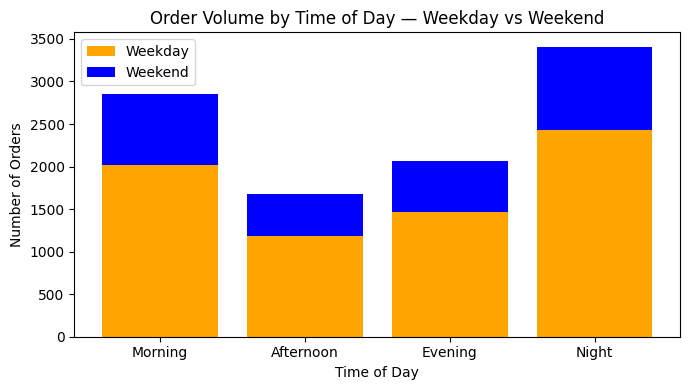

In [27]:
stacked_data = df.groupby(['Time_of_Day', 'is_weekend'])['order_id'].count().unstack()
stacked_data = stacked_data.reindex(['Morning', 'Afternoon', 'Evening', 'Night'])
stacked_data.columns = ['Weekday', 'Weekend']

plt.style.use('default')
plt.figure(figsize=(7, 4))
plt.bar(stacked_data.index, stacked_data['Weekday'], label='Weekday', color='orange')
plt.bar(stacked_data.index, stacked_data['Weekend'], bottom=stacked_data['Weekday'], label='Weekend', color='b')

plt.title('Order Volume by Time of Day — Weekday vs Weekend')
plt.xlabel('Time of Day')
plt.ylabel('Number of Orders')
plt.legend()
plt.tight_layout()
plt.show()

2. Which hour of the day has the most orders?

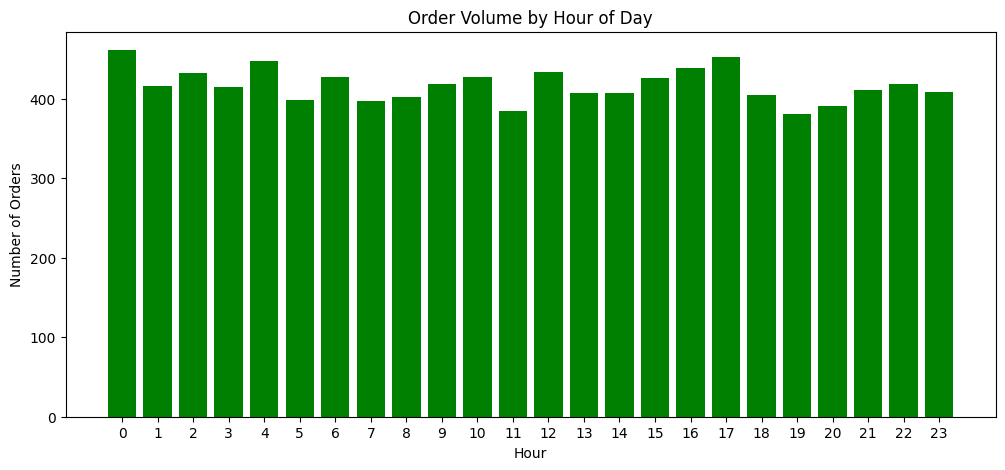

In [28]:
orders_by_hour = df.groupby('hour')['order_id'].count()

plt.figure(figsize=(12, 5))
plt.bar(orders_by_hour.index, orders_by_hour.values, color='g')
plt.title('Order Volume by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Number of Orders')
plt.xticks(range(0, 24))

plt.show()

3. Which city has the highest number of orders?

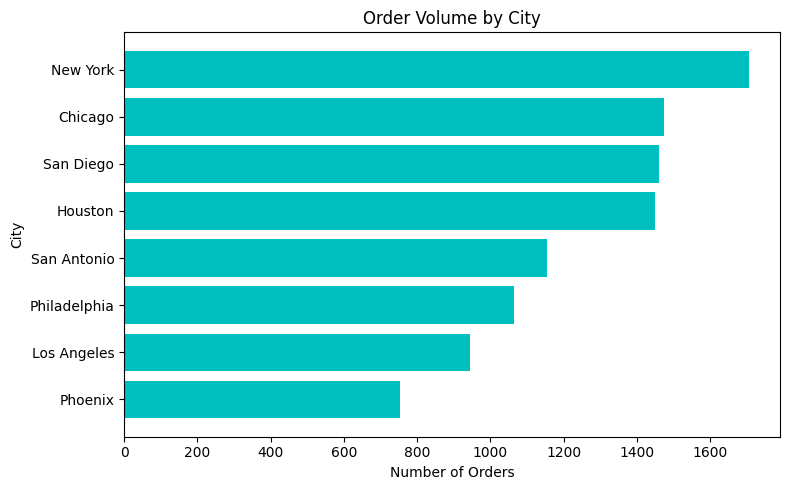

In [29]:
orders_by_city = df.groupby('restaurant_city')['order_id'].count().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
plt.barh(orders_by_city.index, orders_by_city.values, color='c')
plt.title('Order Volume by City')
plt.xlabel('Number of Orders')
plt.ylabel('City')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

4. How does total_amount vary across loyalty tiers?

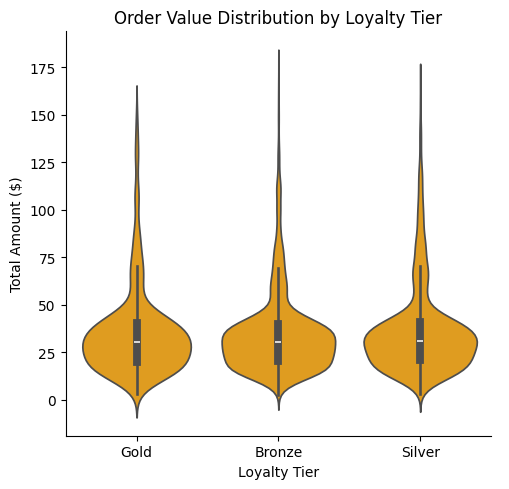

In [30]:
# sns catplot

sns.catplot(data=df, x='customer_loyalty_tier', y='total_amount',
            kind='violin', height=5, color='orange')

plt.title('Order Value Distribution by Loyalty Tier')
plt.xlabel('Loyalty Tier')
plt.ylabel('Total Amount ($)')
plt.tight_layout()
plt.show()

5. Delivery duration by city

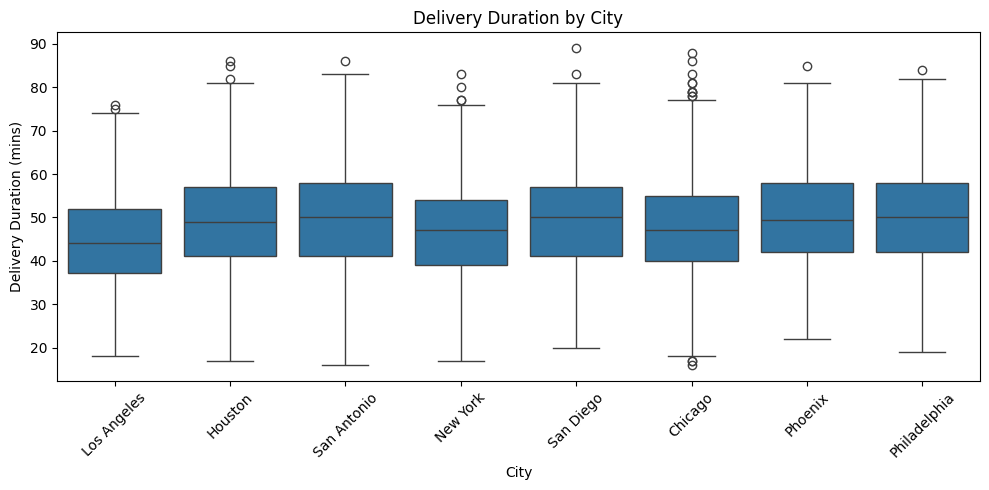

In [31]:
# sns Boxplot

plt.figure(figsize=(10, 5))
sns.boxplot(data=df_delivered, x='restaurant_city', y='delivery_duration_actual', orient='v')
plt.title('Delivery Duration by City')
plt.xlabel('City')
plt.ylabel('Delivery Duration (mins)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

6. Which cuisine has the highest rated restaurants?

restaurant_cuisine
Chinese          4.29
American         4.08
Italian          4.07
Japanese         4.06
Fast Food        3.99
Indian           3.93
Mediterranean    3.84
Mexican          3.77
Name: restaurant_rating, dtype: float64


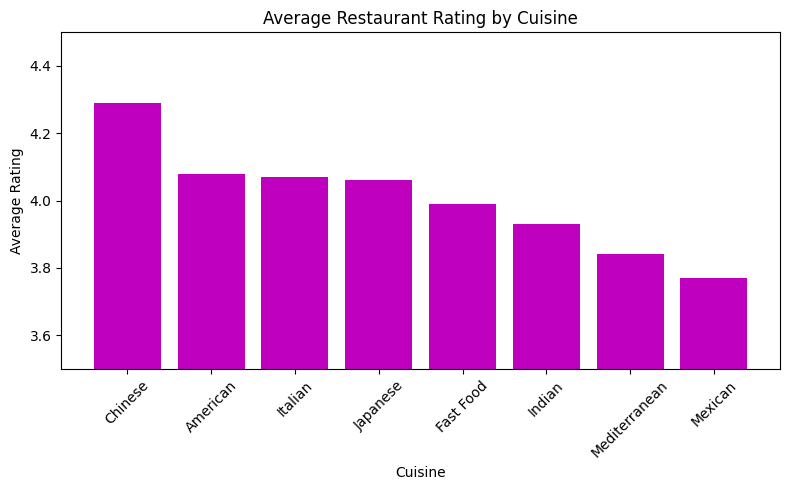

In [32]:
cuisine_rating = df.groupby('restaurant_cuisine')['restaurant_rating'].mean().round(2).sort_values(ascending=False)
print(cuisine_rating)

# bar chart

plt.style.use('default')
plt.figure(figsize=(8, 5))
plt.bar(cuisine_rating.index, cuisine_rating.values, color='m')
plt.title('Average Restaurant Rating by Cuisine')
plt.xlabel('Cuisine')
plt.ylabel('Average Rating')
plt.ylim(3.5, 4.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

7. Order share by acquisition channel

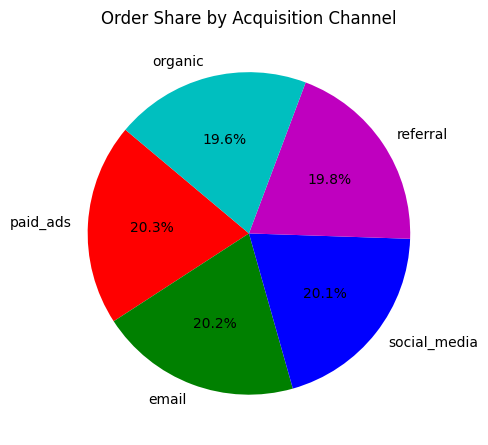

In [33]:
channel_counts = df['customer_acquisition_channel'].value_counts()

plt.figure(figsize=(5,5))
col=['r','g','b','m','c']
plt.pie(channel_counts.values, labels=channel_counts.index, autopct='%1.1f%%', colors = col, startangle=140)
plt.title('Order Share by Acquisition Channel')
plt.tight_layout()
plt.show()

8. Order status share

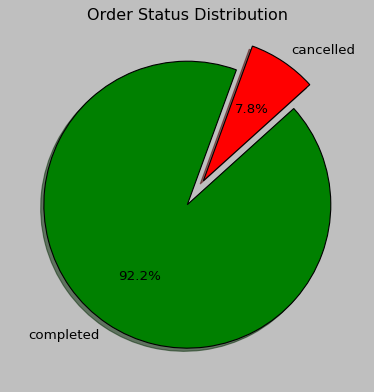

In [34]:
status_counts = df['order_status'].value_counts()

plt.style.use('classic')
plt.figure(figsize=(5,5))
plt.pie(status_counts.values, labels=status_counts.index, autopct='%1.1f%%',
        colors=['green', 'red'], startangle=70, shadow = True, explode = [0.0,0.2])
plt.title('Order Status Distribution')
plt.tight_layout()
plt.show()

9. Average order value by month

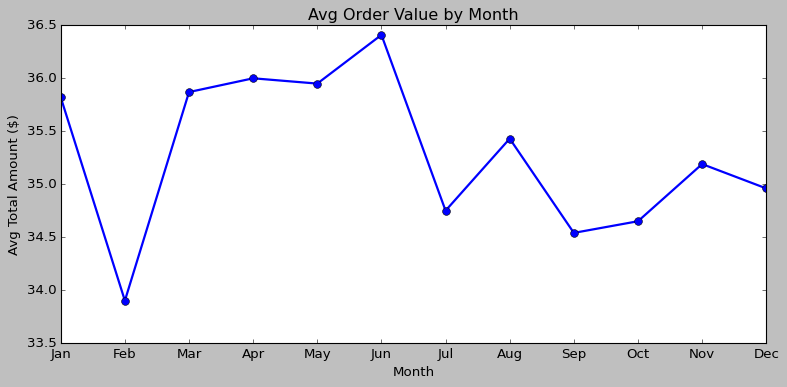

In [35]:
monthly_avg = df.groupby('month_name')['total_amount'].mean().round(2)
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

plt.figure(figsize=(10, 5))
plt.plot(month_names, monthly_avg.values, marker='o', color='blue', linewidth=2, markersize=7)
plt.title('Avg Order Value by Month')
plt.xlabel('Month')
plt.ylabel('Avg Total Amount ($)')
plt.tight_layout()
plt.show()

10. Delivery duration distribution

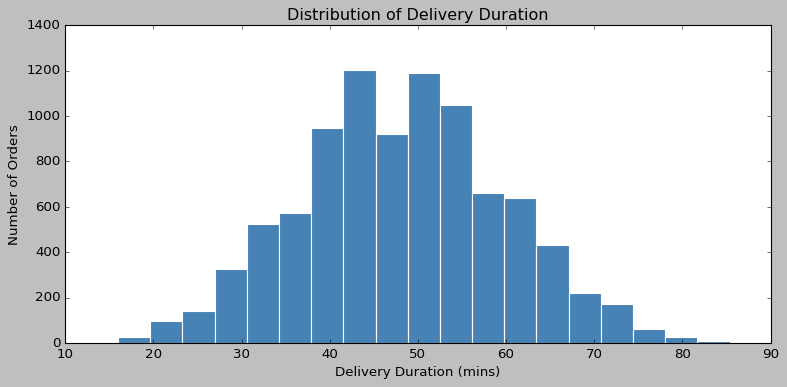

In [36]:
# Histogram

plt.figure(figsize=(10, 5))
plt.hist(df_delivered['delivery_duration_actual'], bins=20, color='steelblue', edgecolor='white')
plt.title('Distribution of Delivery Duration')
plt.xlabel('Delivery Duration (mins)')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.show()

11. Does higher precipitation increase delivery time?

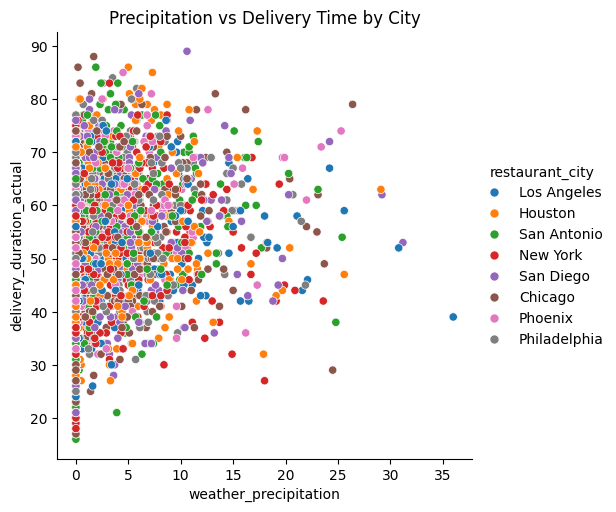

'Each dot is one order. The x-axis shows how much it was raining, the y-axis shows how long the delivery took.\nIf dots drift upward as we move right, rain increases delivery time.\nIf dots stay flat across, rain has no effect.\nIn this chart dots are heavily clustered on the left (low precipitation) with a very slight upward drift as precipitation increases - confirming the weak positive relationship")'

In [37]:
plt.style.use("default")
sns.relplot(x='weather_precipitation', y='delivery_duration_actual',
            hue='restaurant_city', data=df_delivered)
plt.title('Precipitation vs Delivery Time by City')
plt.show()

'''Each dot is one order. The x-axis shows how much it was raining, the y-axis shows how long the delivery took.
If dots drift upward as we move right, rain increases delivery time.
If dots stay flat across, rain has no effect.
In this chart dots are heavily clustered on the left (low precipitation) with a very slight upward drift as precipitation increases - confirming the weak positive relationship")'''

## **Conclusion**
**Customer Behaviour**
- People order the most at **Night**, least in the **Afternoon**
- Orders are spread evenly across all 24 hours - no single hour spikes
- **New York** gets the most orders, **Phoenix** the least

**Order Value & Loyalty**
- All loyalty tiers spend almost the same - Gold doesn't spend more than Bronze
- Weekend vs weekday spending difference is negligible

**Delivery**
- **Phoenix & San Antonio** are the slowest cities to deliver
- **Los Angeles** is the fastest
- Rain does slow deliveries slightly. The bigger drivers of delivery time are likely city, restaurant prep time and distance - not weather.
- Most deliveries finish around **48 minutes** - very consistent

**Ratings & Cuisine**
- **Chinese** restaurants are rated the highest
- **Mexican** restaurants are rated the lowest despite good order volume
- Overall all cuisines are rated well - no cuisine is performing badly

**Acquisition & Orders**
- All 5 marketing channels bring in equal customers - no channel stands out
- **92.25%** orders are completed, only **7.75%** are cancelled - healthy numbers

**Revenue**
- Total Order value stays flat across all months - no seasonal spikes
- July is the best month, August the weakest - but difference is very small

**Overall Summary**

Platform runs smoothly and consistently. The biggest opportunities for improvement are in Phoenix and San Antonio delivery performance, understanding why loyalty tier doesn't drive higher spending (Gold customers should be spending more than Bronze), and investigating why Mexican cuisine is rated the lowest despite strong order volume.